# Bagian B — Library Python untuk Data Science

**Fundamen Sains Data: Pengantar Python untuk Sains Data, Probabilitas, dan Statistika**
Program Studi Informatika, Program Sarjana, Universitas Islam Indonesia

Bagian ini memperkenalkan tiga library inti, **NumPy**, **pandas**, dan **Matplotlib**, dengan
contoh nilai ujian dan durasi belajar mahasiswa. SciPy diperkenalkan di Bagian C saat membahas
distribusi probabilitas.

---
## B.1 Mengimpor library

Perintah `import nama_library as alias` memuat library dan memberinya nama pendek. Alias `np`,
`pd`, dan `plt` dipakai di hampir semua dokumentasi, sehingga sebaiknya diikuti. Letakkan cell
impor di awal notebook dan jalankan lagi setiap kali runtime dimulai ulang.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np                 # perhitungan numerik
import pandas as pd                # data tabel
import matplotlib.pyplot as plt    # grafik

print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)

NumPy  : 2.4.3
pandas : 3.0.1


**Hasil yang diharapkan.** Dua baris berisi nomor versi, misalnya `NumPy  : 2.0.2` dan
`pandas : 2.2.2`. Nomor versi dapat berbeda karena Colab memperbarui library secara berkala.
Pesan `ModuleNotFoundError` berarti library belum terpasang.

---
## B.2 Array NumPy

**Array NumPy** (`ndarray`) mirip list, tetapi dirancang untuk perhitungan numerik. Operasi
matematika pada array diterapkan ke setiap elemen (*element-wise*), sedangkan pada list operasi
yang sama berarti hal lain: `* 2` menggandakan isi list, dan `+ 5` menghasilkan galat. Array
juga menyediakan fungsi statistik siap pakai dan jauh lebih cepat untuk data besar.

**Contoh kasus.** Nilai kuis lima mahasiswa akan diberi bonus 5 poin dan dikonversi ke skala 0
sampai 4. Bandingkan hasil operasi pada list dan array, lalu ambil nilai yang minimal 80.

In [2]:
nilai_list = [70, 85, 90, 65, 80]
nilai_array = np.array(nilai_list)

print("List * 2  :", nilai_list * 2)
print("Array * 2 :", nilai_array * 2)

# Operasi element-wise
print("Nilai + bonus :", nilai_array + 5)
print("Skala 0-4     :", nilai_array / 100 * 4)

# Statistik ringkas
print("Rata-rata :", nilai_array.mean())
print("Maksimum  :", nilai_array.max())

# Filter dengan kondisi (boolean indexing)
print("Nilai >= 80 :", nilai_array[nilai_array >= 80])

List * 2  : [70, 85, 90, 65, 80, 70, 85, 90, 65, 80]
Array * 2 : [140 170 180 130 160]
Nilai + bonus : [75 90 95 70 85]
Skala 0-4     : [2.8 3.4 3.6 2.6 3.2]
Rata-rata : 78.0
Maksimum  : 90
Nilai >= 80 : [85 90 80]


**Hasil yang diharapkan.**

```text
List * 2  : [70, 85, 90, 65, 80, 70, 85, 90, 65, 80]
Array * 2 : [140 170 180 130 160]
Nilai + bonus : [75 90 95 70 85]
Skala 0-4     : [2.8 3.4 3.6 2.6 3.2]
Rata-rata : 78.0
Maksimum  : 90
Nilai >= 80 : [85 90 80]
```

**Interpretasi.** Operasi `* 2` pada list menghasilkan sepuluh elemen (isi diulang), sedangkan
pada array setiap nilai dikalikan dua. Ekspresi `nilai_array >= 80` menghasilkan array boolean;
ketika dipakai di dalam kurung siku, hanya elemen bernilai `True` yang diambil. Teknik *boolean
indexing* ini sangat sering dipakai untuk memfilter data.

---
## B.3 DataFrame pandas

**DataFrame** adalah tabel pandas yang terdiri atas baris dan kolom, seperti lembar kerja
spreadsheet. Setiap kolomnya adalah **Series**, yaitu deret data satu dimensi berlabel.
DataFrame dapat dibuat dari dictionary: kunci menjadi nama kolom, dan list menjadi isi kolom.
Operasi dasar yang paling sering dipakai adalah:

- `df.head(n)` menampilkan `n` baris pertama, dan `df.shape` memberi jumlah baris dan kolom.
- `df["kolom"]` memilih satu kolom, sedangkan `df[["k1", "k2"]]` memilih beberapa kolom.
- `df[kondisi]` memfilter baris yang memenuhi kondisi.

**Contoh kasus.** Data delapan mahasiswa berisi nama, durasi belajar per minggu, dan nilai ujian.
Tampilkan data awal, lalu cari mahasiswa dengan nilai minimal 80.

In [3]:
data_mahasiswa = {
    "nama": ["Ani", "Budi", "Citra", "Dodi", "Eka", "Fajar", "Gita", "Hana"],
    "durasi_belajar": [4, 6, 8, 3, 10, 7, 5, 9],      # jam per minggu
    "nilai": [62, 70, 81, 58, 92, 76, 68, 88],
}
df = pd.DataFrame(data_mahasiswa)

print(df.head())
print("Ukuran tabel:", df.shape)

# Memfilter baris: mahasiswa dengan nilai minimal 80
print(df[df["nilai"] >= 80][["nama", "durasi_belajar", "nilai"]])

# Rata-rata satu kolom
print(f"Rata-rata durasi belajar: {df['durasi_belajar'].mean():.2f} jam per minggu")

    nama  durasi_belajar  nilai
0    Ani               4     62
1   Budi               6     70
2  Citra               8     81
3   Dodi               3     58
4    Eka              10     92
Ukuran tabel: (8, 3)
    nama  durasi_belajar  nilai
2  Citra               8     81
4    Eka              10     92
7   Hana               9     88
Rata-rata durasi belajar: 6.50 jam per minggu


**Hasil yang diharapkan.**

```text
    nama  durasi_belajar  nilai
0    Ani               4     62
1   Budi               6     70
2  Citra               8     81
3   Dodi               3     58
4    Eka              10     92
Ukuran tabel: (8, 3)
    nama  durasi_belajar  nilai
2  Citra               8     81
4    Eka              10     92
7   Hana               9     88
Rata-rata durasi belajar: 6.50 jam per minggu
```

**Interpretasi.** Angka di sisi kiri tabel adalah indeks baris, yang dimulai dari 0. Filter
menghasilkan tiga mahasiswa (Citra, Eka, dan Hana), dan ketiganya memiliki durasi belajar relatif
tinggi (8 sampai 10 jam). Dugaan adanya hubungan ini diperiksa dengan grafik berikutnya. Di Colab,
menulis `df` sendirian di baris terakhir cell menampilkan tabel dalam format yang lebih rapi
daripada `print(df)`.

In [4]:
# Menampilkan DataFrame dalam format tabel yang lebih rapi (seperti di Colab)
df

,nama,durasi_belajar,nilai
0,Ani,4,62
1,Budi,6,70
2,Citra,8,81
3,Dodi,3,58
4,Eka,10,92
5,Fajar,7,76
6,Gita,5,68
7,Hana,9,88


---
## B.4 Grafik dengan Matplotlib

Matplotlib membuat grafik melalui modul `pyplot` (`plt`) dengan pola empat langkah: siapkan
kanvas dengan `plt.figure(figsize=(lebar, tinggi))`, panggil fungsi grafik seperti
`plt.scatter()` atau `plt.bar()`, tambahkan judul serta label sumbu, lalu tampilkan dengan
`plt.show()`. Judul dan label sumbu sebaiknya selalu ditulis agar grafik dapat dibaca orang lain.

**Contoh kasus.** Apakah mahasiswa yang belajar lebih lama cenderung memperoleh nilai lebih
tinggi? Buat diagram pencar (*scatter plot*) durasi belajar terhadap nilai, lalu diagram batang
nilai per mahasiswa.

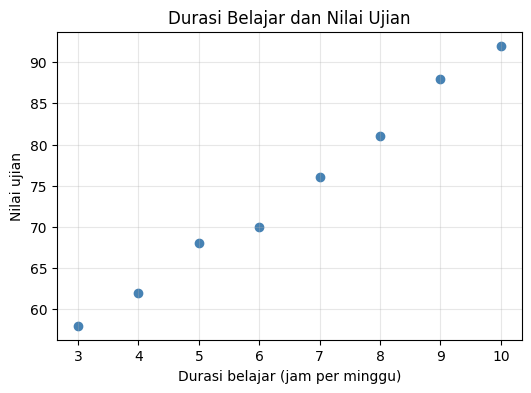

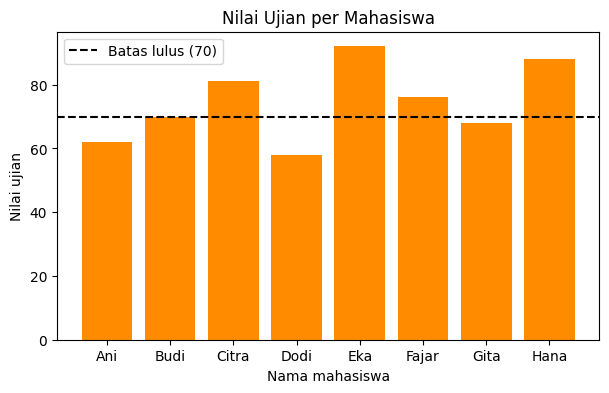

In [5]:
# Diagram pencar: hubungan dua variabel numerik
plt.figure(figsize=(6, 4))
plt.scatter(df["durasi_belajar"], df["nilai"], color="steelblue")
plt.title("Durasi Belajar dan Nilai Ujian")
plt.xlabel("Durasi belajar (jam per minggu)")
plt.ylabel("Nilai ujian")
plt.grid(alpha=0.3)
plt.show()

# Diagram batang: membandingkan nilai antarmahasiswa
plt.figure(figsize=(7, 4))
plt.bar(df["nama"], df["nilai"], color="darkorange")
plt.axhline(70, color="black", linestyle="--", label="Batas lulus (70)")
plt.title("Nilai Ujian per Mahasiswa")
plt.xlabel("Nama mahasiswa")
plt.ylabel("Nilai ujian")
plt.legend()
plt.show()

**Hasil yang diharapkan.** Dua grafik, yaitu **Gambar 7** dan **Gambar 8** pada modul. Grafik
pertama berisi delapan titik; setiap titik mewakili satu mahasiswa, dengan posisi horizontal
menunjukkan durasi belajar dan posisi vertikal menunjukkan nilai. Titik-titik membentuk pola naik
dari kiri bawah ke kanan atas. Grafik kedua berisi delapan batang dengan garis putus-putus
horizontal pada nilai 70.

**Interpretasi.** Pola naik pada diagram pencar menunjukkan hubungan **positif**: semakin lama
durasi belajar, nilai cenderung semakin tinggi. Hubungan ini tidak otomatis berarti durasi belajar
*menyebabkan* nilai naik, karena faktor lain bisa berpengaruh. Pada diagram batang, batang yang
tidak mencapai garis putus-putus menunjukkan mahasiswa dengan nilai di bawah 70 (Ani, Dodi, dan
Gita).

Dengan NumPy, pandas, dan Matplotlib, mahasiswa sudah memiliki alat untuk menghitung statistik dan
mensimulasikan probabilitas pada Bagian C.